## Урок 3. Домашнее задание

### 3.1 Задание среднего уровня.

В домашней работе предлагается применить PCA трехмерным данным по оттоку, которые содержатся в файле `data/client_segmentation.csv`. В файле содержится информация по клиентам оператора связи о том, как изменилось потребление услуг оператора за два месяца:
* call_diff доля звонков
* sms_diff доля смс
* доля интернет-трафика traffic_diff

Все показатели вычисляются по формуле

$$
\frac{\text{new_value}-\text{old_value}}{\text{old_value}}
$$

В последней колонке customes_class содержится метка по оттоку:
* $0$ - активный пользователя
* $1$ - "спящий" пользователь (редко пользуется услугами)
* $2$ - пользователь, который ушел в отток

Получается у нас три фичи (датасет трёхмерный) и задача классификации на три класса.

загружаем датасет в память

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
df_source = pd.read_csv('client_segmentation.csv')
X = df_source[['call_diff','sms_diff','traffic_diff']].values
y = df_source.customes_class.values

df_source.head()

,call_diff,sms_diff,traffic_diff,customes_class
0,-0.666421,0.444911,-0.273538,0.0
1,-0.889273,-0.537896,-1.959469,2.0
2,-0.841503,0.846665,0.727606,0.0
3,1.389749,0.390911,1.789246,1.0
4,-1.228211,-1.375899,-1.434209,2.0


**В рамках домашнего задания**

1. Визуализируйте первый и третий столбец из набора данных `call_diff` и`traffic_diff` в виде scatter
2. Постройте PCA  сожмите их до одномерного случая, визуализируйте результат


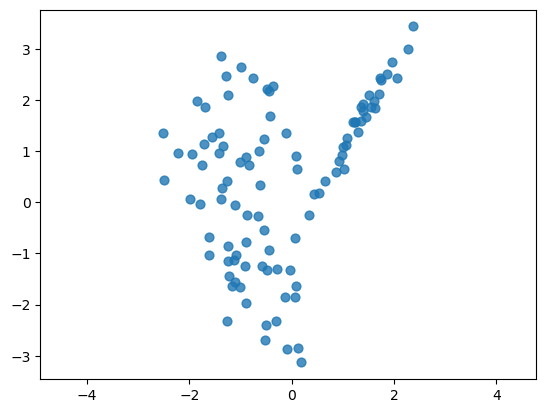

In [3]:
#визуализация
import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(df_source['call_diff'], df_source['traffic_diff'], s=40,  marker='o', alpha=0.8)
plt.axis('equal')
plt.show()

In [4]:
from sklearn.decomposition import PCA
#читаем df
df_source1 = pd.read_csv('client_segmentation.csv')
#выбираем и преобразуем в Np массив
X1 = df_source[['call_diff','traffic_diff']].values
#выбираем метки классов
y1 = df_source.customes_class.values
#понижаем размерность и обучаем модель преобразовать данные
pca = PCA(n_components=1).fit(X1)
#применяем РСА
X_pca = pca.transform(X1)
X_pca[:10]


array([[-0.86388574],
       [-2.46273415],
       [-0.05616347],
       [ 1.91449524],
       [-2.15285129],
       [ 0.83453235],
       [ 1.6551052 ],
       [-1.84171309],
       [-2.29403214],
       [ 1.49844584]])

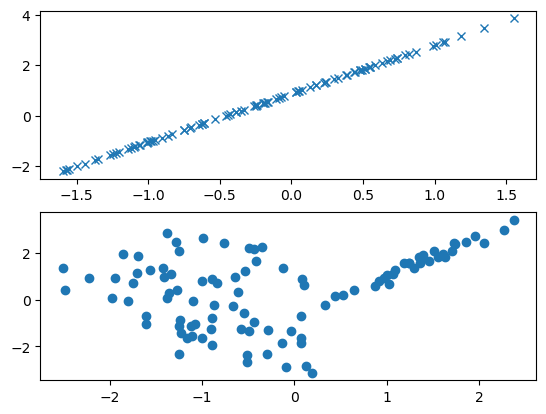

In [5]:
#производим преобразование одномерного массива в двумерный для визуализации
X_new = pca.inverse_transform(X_pca)

plt.figure(1)
plt.subplot(211)
plt.plot(X_new[:,0], X_new[:,1], 'x')
#визуализация исходных точек
plt.subplot(212)
plt.plot(X1[:,0], X1[:,1], 'o')
plt.show()


### 3.2 Задание высокого уровня

Сжимать двумерные данные не очень интересно, давайте попробуем применить PCA к трёхмерному датасету и сжать данные до размерности $n=2$.

Для наглядности и визуализируем наши трёхмерные данные в 3D:

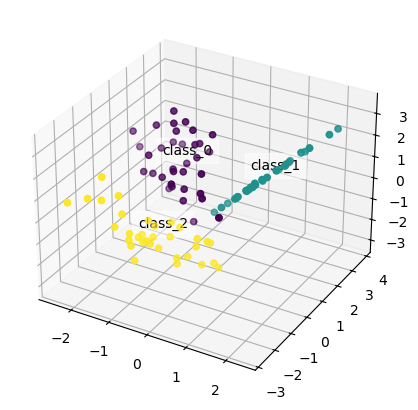

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib inline
# и визуализируем их
fig = plt.figure(1, figsize=(6, 5))
plt.clf()
ax = fig.add_subplot(111, projection='3d')  
num_labels = np.unique(y).size
for name, label in [('class_%d' % i, i) for i in range(num_labels)]:
    ax.text3D(X[y == label, 0].mean(), X[y == label, 1].mean() + 0.5,
        X[y == label, 2].mean(), name, horizontalalignment='center',
        bbox=dict(alpha=.5, edgecolor='w', facecolor='w'))
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis')
plt.show()

С помощью класса `sklearn.decomposition.PCA` выполните понижение размерности признакового пространства  с $n=3$ до $n=2$ и снова визуализируйте данные. Картинка должна получится примерно такая:
![classification_dim_reduction](https://248006.selcdn.ru/public/DS.%20Block%202.%20M8/classification_dim_reduction.png)

In [7]:
df_source = pd.read_csv('client_segmentation.csv')
X = df_source[['call_diff','sms_diff','traffic_diff']].values
#выьираем метки классов
y = df_source.customes_class.values
#понижаем размерность и обучаем модель преобразовать данные
pca = PCA(n_components=2).fit(X)  
#применяем РСА
X_pca = pca.transform(X)   


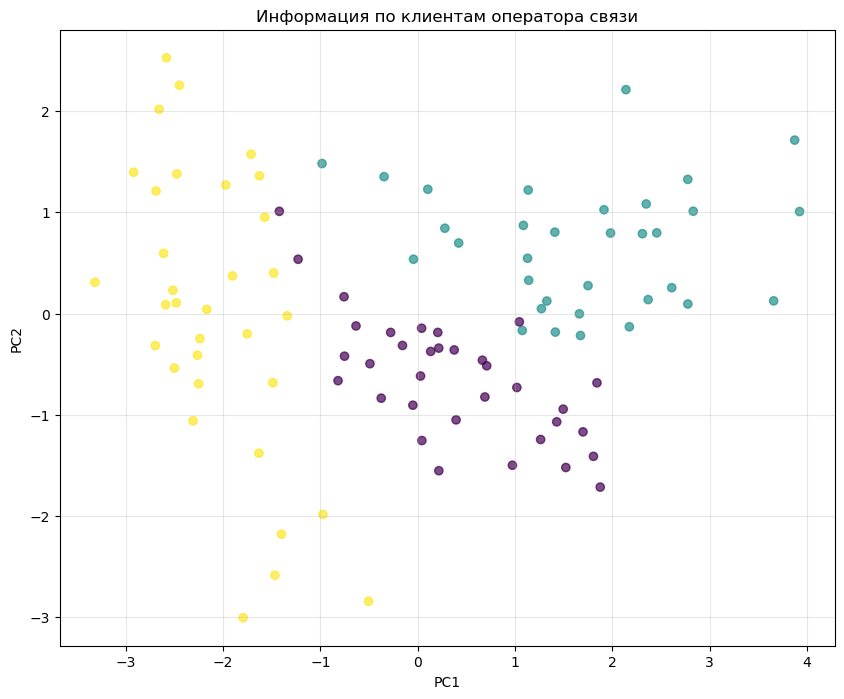

In [8]:
import numpy as np
plt.figure(figsize=(10, 8))

#рисуем все точки
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Информация по клиентам оператора связи')

plt.grid(True, alpha=0.3)
plt.show()


В этом уроке мы научились применять алгоритм PCA  понизили размерность датасета с $n=2$ до $n=1$.

В следующем уроке мы реализуем алгоритм PCA на языке python по шагам.